In [ ]:
import pandas as pd
df=pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


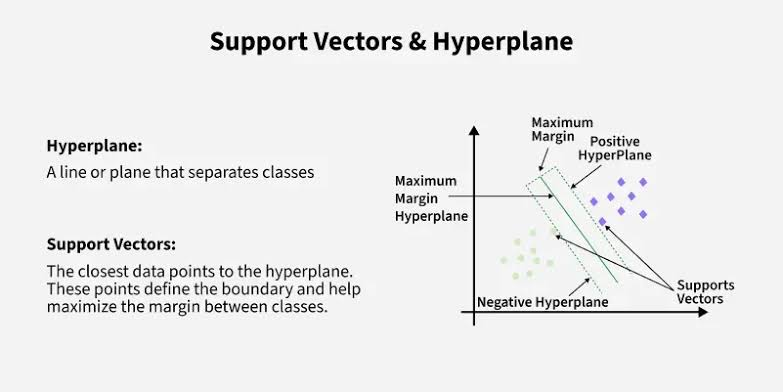

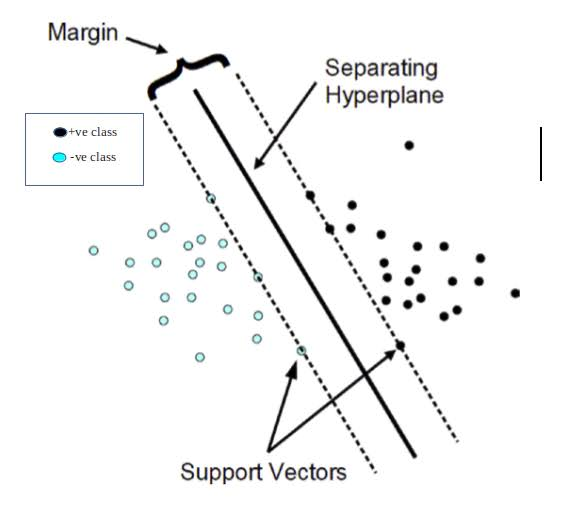

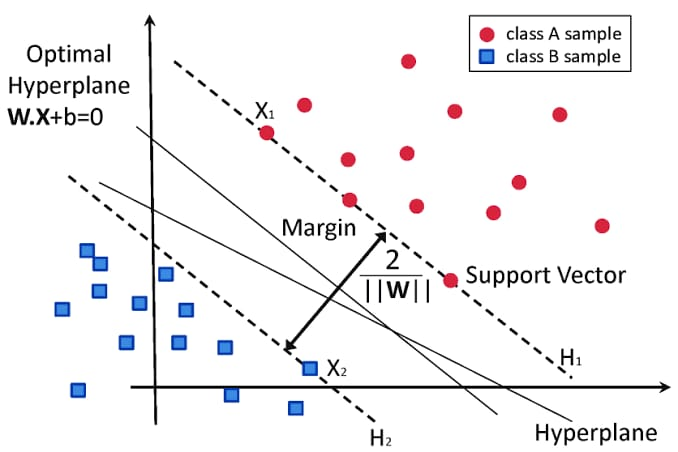

In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Glucose']

,Glucose
0,148
1,85
2,183
3,89
4,137
...,...
763,101
764,122
765,121
766,126


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.rename(columns={"DiabetesPedigreeFunction":"DPF"},inplace=True)
df.rename(columns={"Outcome":"class"},inplace=True)
df.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [ ]:
df['class'].value_counts()   #synthetic minority oversampling technique

,count
class,
0,500
1,268


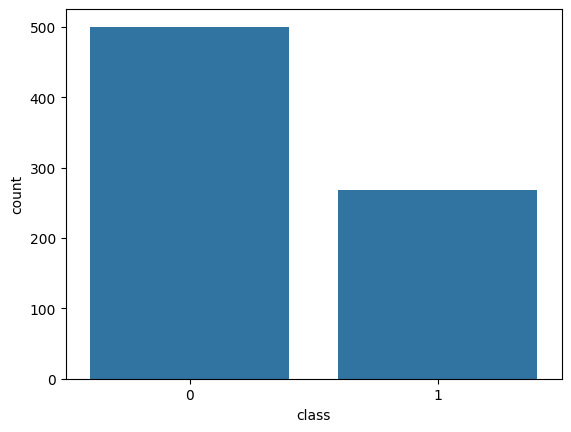

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=df["class"])
plt.show()

In [ ]:
#from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler                      #file
                                                                             #prefernce                                                                            # settings                                                                            #env(search)                                                                            #windows option click                                                                            #open("SCIPY_ARRAY_API":"1")
x=df.drop(columns="class",axis=1)
y=df["class"]
#smote=SMOTE(sampling_strategy="minority")
smote= RandomUnderSampler(sampling_strategy="majority")                   #pip install imbalanced-learn scikit-learn -y
x_sm,y_sm=smote.fit_resample(x,y)                                          ##reinstall with compatible version

                                                                           #pip install scikit-learn==1.3.2 imbalanced-learn==0.1                                                                       # reinstall kernal
                                                                           #from imblearn.over_sampling import SMOT                                                                          #print(imblearn._version_)
print(x_sm.shape)
print(y_sm.shape)

(536, 8)
(536,)


In [ ]:
y_sm.value_counts()

,count
class,
0,268
1,268


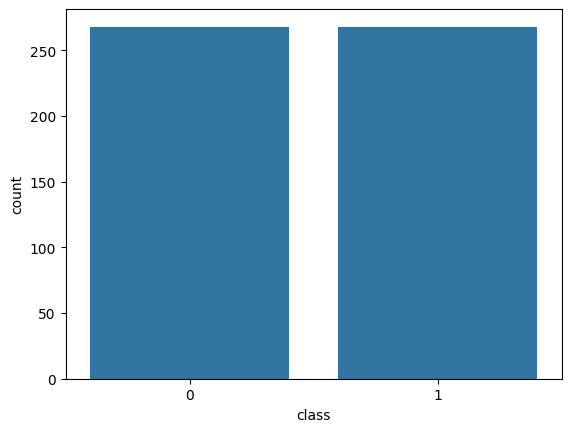

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=y_sm)
plt.show()

In [ ]:
x=df.drop(columns="class")

y=df["class"]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
y

,class
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
#from sklearn.preprocessing import StandardScaler
#scaler=StandardScaler()
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x=scaler.fit_transform(x)
x

array([[0.35294118, 0.74371859, 0.59016393, ..., 0.50074516, 0.23441503,
        0.48333333],
       [0.05882353, 0.42713568, 0.54098361, ..., 0.39642325, 0.11656704,
        0.16666667],
       [0.47058824, 0.91959799, 0.52459016, ..., 0.34724292, 0.25362938,
        0.18333333],
       ...,
       [0.29411765, 0.6080402 , 0.59016393, ..., 0.390462  , 0.07130658,
        0.15      ],
       [0.05882353, 0.63316583, 0.49180328, ..., 0.4485842 , 0.11571307,
        0.43333333],
       [0.05882353, 0.46733668, 0.57377049, ..., 0.45305514, 0.10119556,
        0.03333333]])

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)
model=SVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7662337662337663
[[91 13]
 [23 27]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.83       104
           1       0.68      0.54      0.60        50

    accuracy                           0.77       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.76      0.77      0.76       154



In [ ]:
model.fit(x_test,y_test)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8051948051948052
[[94 10]
 [20 30]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       104
           1       0.75      0.60      0.67        50

    accuracy                           0.81       154
   macro avg       0.79      0.75      0.76       154
weighted avg       0.80      0.81      0.80       154



In [ ]:
model=SVC(C=100,kernel ="rbf",gamma=0.3,shrinking=False,break_ties=True)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7662337662337663
[[91 13]
 [23 27]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.83       104
           1       0.68      0.54      0.60        50

    accuracy                           0.77       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.76      0.77      0.76       154



In [ ]:
model=SVC(C=10,kernel="rbf",gamma=0.3,shrinking=True)
model.fit(x_test,y_test)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7922077922077922
[[92 12]
 [20 30]]
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       104
           1       0.71      0.60      0.65        50

    accuracy                           0.79       154
   macro avg       0.77      0.74      0.75       154
weighted avg       0.79      0.79      0.79       154



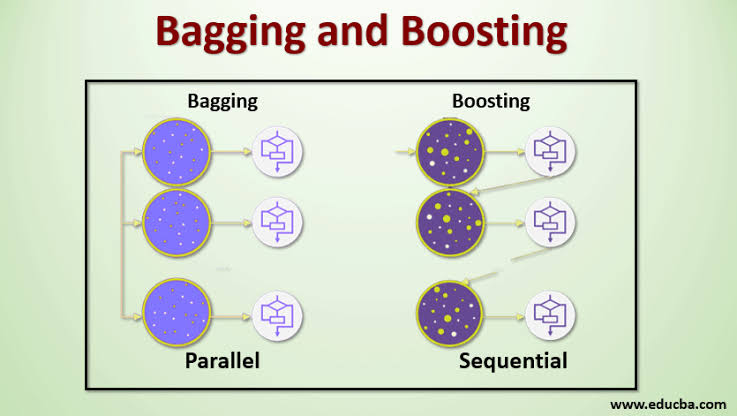

In [ ]:
from sklearn.model_selection import GridSearchCV
param={"C":[0.1,1,10,50,100,500],"gamma":[1,0.5,0.1,0.01,0.001]}
grid=GridSearchCV(SVC(),param,refit=True,verbose=2)
grid.fit(x_train,y_train)
grid_pred=grid.predict(x_test)
print(accuracy_score(y_test,grid_pred))
print(confusion_matrix(y_test,grid_pred))
print(classification_report(y_test,grid_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0

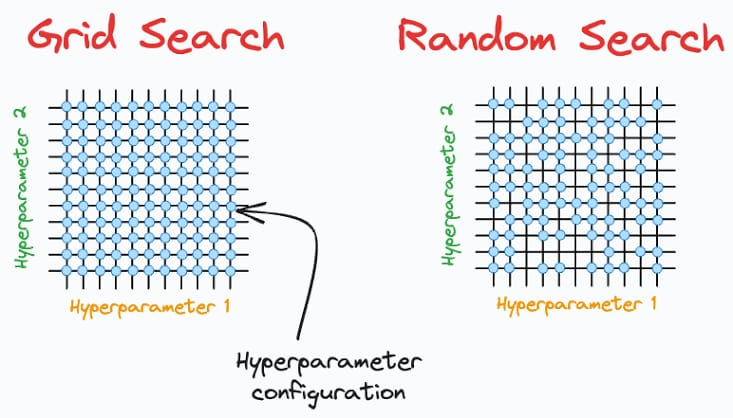

\

In [ ]:
from sklearn.model_selection import GridSearchCV
param={"C":[0.1,1,10,50,100,500],"gamma":[1,0.5,0.1,0.01,0.001]}
grid=GridSearchCV(SVC(),param,refit=True,verbose=2)
grid.fit(x_test,y_test)
grid_pred=grid.predict(x_test)
print(accuracy_score(y_test,grid_pred))
print(confusion_matrix(y_test,grid_pred))
print(classification_report(y_test,grid_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.5; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0

*GridSearchCV* and *RandomizedSearchCV* are both hyperparameter tuning methods in machine learning, especially used with *scikit-learn*. Here's a clear comparison:

---

### 🔍 *1. Search Strategy*

| Feature      | *GridSearchCV*                                 | *RandomizedSearchCV*                                  |
| ------------ | ------------------------------------------------ | ------------------------------------------------------- |
| *Approach* | Exhaustive search over all possible combinations | Random search over a fixed number of parameter settings |
| *Coverage* | Tests *all combinations*                       | Tests a *subset* of combinations                      |

---

### ⏱ *2. Time & Efficiency*

| Feature      | *GridSearchCV*                  | *RandomizedSearchCV*                 |
| ------------ | --------------------------------- | -------------------------------------- |
| *Speed*    | Slower for large parameter spaces | Faster; can limit number of iterations |
| *Best for* | Small search spaces               | Large or continuous search spaces      |

---

### ⚙ *3. Control*

| Feature          | *GridSearchCV*                        | *RandomizedSearchCV*                            |
| ---------------- | --------------------------------------- | ------------------------------------------------- |
| *User Control* | Full control over tested values         | Must specify distributions or value ranges        |
| *Iterations*   | Automatically based on all combinations | You set n_iter for how many combinations to try |

---

### 🎯 *4. Finding the Best Parameters*

| Feature        | *GridSearchCV*                        | *RandomizedSearchCV*                        |
| -------------- | --------------------------------------- | --------------------------------------------- |
| *Optimality* | Finds best from all tested combinations | May not find the best, but often close enough |

---

### ✅ *When to Use*

* **Use GridSearchCV** when:

  * The number of parameter combinations is small
  * You want the best possible result and can afford more computation

* **Use RandomizedSearchCV** when:

  * The parameter space is large or continuous
  * You need results faster or want to limit computation

---

### ✅ Example Code Comparison

python
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

# Grid Search Example
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}
grid_search = GridSearchCV(model, param_grid, cv=5)

# Random Search Example
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 30)
}
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, cv=5)


---

Would you like a real dataset example for both methods?

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param={"C":[0.1,1,10,50,100,500],"gamma":[1,0.5,0.1,0.01,0.001]}
random=RandomizedSearchCV(SVC(),param,refit=True,verbose=7)
random.fit(x_train,y_train)
random_pred=random.predict(x_test)
print(accuracy_score(y_test,random_pred))
print(confusion_matrix(y_test,random_pred))
print(classification_report(y_test,random_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ..................C=1, gamma=0.001;, score=0.650 total time=   0.0s
[CV 2/5] END ..................C=1, gamma=0.001;, score=0.642 total time=   0.0s
[CV 3/5] END ..................C=1, gamma=0.001;, score=0.642 total time=   0.0s
[CV 4/5] END ..................C=1, gamma=0.001;, score=0.642 total time=   0.0s
[CV 5/5] END ..................C=1, gamma=0.001;, score=0.648 total time=   0.0s
[CV 1/5] END ....................C=500, gamma=1;, score=0.756 total time=   0.1s
[CV 2/5] END ....................C=500, gamma=1;, score=0.732 total time=   0.1s
[CV 3/5] END ....................C=500, gamma=1;, score=0.699 total time=   0.1s
[CV 4/5] END ....................C=500, gamma=1;, score=0.764 total time=   0.1s
[CV 5/5] END ....................C=500, gamma=1;, score=0.762 total time=   0.1s
[CV 1/5] END .................C=500, gamma=0.01;, score=0.805 total time=   0.0s
[CV 2/5] END .................C=500, gamma=0.01;

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param={"C":[0.1,1,10,50,100,500],"gamma":[1,0.5,0.1,0.01,0.001]}
random=RandomizedSearchCV(SVC(),param,refit=True,verbose=7)
random.fit(x_test,y_test)
random_pred=random.predict(x_test)
print(accuracy_score(y_test,random_pred))
print(confusion_matrix(y_test,random_pred))
print(classification_report(y_test,random_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END .................C=50, gamma=0.001;, score=0.677 total time=   0.0s
[CV 2/5] END .................C=50, gamma=0.001;, score=0.677 total time=   0.0s
[CV 3/5] END .................C=50, gamma=0.001;, score=0.677 total time=   0.0s
[CV 4/5] END .................C=50, gamma=0.001;, score=0.677 total time=   0.0s
[CV 5/5] END .................C=50, gamma=0.001;, score=0.667 total time=   0.0s
[CV 1/5] END .................C=10, gamma=0.001;, score=0.677 total time=   0.0s
[CV 2/5] END .................C=10, gamma=0.001;, score=0.677 total time=   0.0s
[CV 3/5] END .................C=10, gamma=0.001;, score=0.677 total time=   0.0s
[CV 4/5] END .................C=10, gamma=0.001;, score=0.677 total time=   0.0s
[CV 5/5] END .................C=10, gamma=0.001;, score=0.667 total time=   0.0s
[CV 1/5] END ...................C=50, gamma=0.1;, score=0.742 total time=   0.0s
[CV 2/5] END ...................C=50, gamma=0.1;

Here’s a clear and concise definition of *Bagging* and *Boosting* in machine learning:

---

### *Bagging (Bootstrap Aggregating):*

* *Definition*: Bagging is an ensemble technique that trains multiple models (usually of the same type) on different random subsets of the training data (with replacement) and then combines their outputs to improve overall performance.
* *Goal: Reduce **variance* and prevent *overfitting*.
* *Example algorithm*: Random Forest.

*Key Features:*

* Parallel training.
* Each model sees a different dataset.
* Final output is based on majority voting (classification) or averaging (regression).

---

### *Boosting:*

* *Definition: Boosting is an ensemble technique that builds models **sequentially, where each model tries to **correct the errors* of the previous one.
* *Goal: Reduce **bias* and *variance*, leading to strong prediction.
* *Example algorithms*: AdaBoost, Gradient Boosting, XGBoost.

*Key Features:*

* Sequential training.
* Focuses more on hard-to-predict instances.
* Final output is a weighted combination of models.

---

Let me know if you'd like code examples or a comparison table!

In [ ]:
#boosting
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier(estimator=SVC(probability=True),n_estimators=100)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.6753246753246753
[[104   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       104
           1       0.00      0.00      0.00        50

    accuracy                           0.68       154
   macro avg       0.34      0.50      0.40       154
weighted avg       0.46      0.68      0.54       154



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 🔥 *Boosting in Machine Learning – Explained*

*Boosting* is an *ensemble learning technique* that combines the output of *multiple weak learners* (usually decision trees) to create a *strong learner* with better performance.

---

### ✅ *Key Idea of Boosting*

* Train models *sequentially*, each one correcting the errors of the previous.
* Later models focus more on the *misclassified samples*.
* Final prediction is a *weighted sum* (for regression) or *majority vote* (for classification).

---

### 📌 *Why Boosting Works*

* Reduces both *bias* and *variance*.
* Handles overfitting better than bagging in many cases.
* Improves accuracy by combining *many weak models*.

---

## 🧠 *Types of Boosting Algorithms*

| Type | Description |
| ---- | ----------- |

### 1. *AdaBoost (Adaptive Boosting)*

* Focuses on misclassified samples by increasing their weights.
* Uses weighted majority voting.
* Simple and effective on clean datasets.
* Base learners: usually *Decision Stumps (1-level trees)*.

python
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=100)


---

### 2. *Gradient Boosting*

* Builds trees *sequentially* to minimize a *loss function* (like MSE, log loss).
* Each tree predicts the *residual errors* of the previous tree.
* More flexible than AdaBoost.

python
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)


---

### 3. *XGBoost (Extreme Gradient Boosting)*

* Optimized version of Gradient Boosting (faster, regularized).
* Very popular in Kaggle competitions.
* Handles missing values, parallel processing, and regularization.

python
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=100, learning_rate=0.1)


---

### 4. *LightGBM (Light Gradient Boosting Machine)*

* Uses *histogram-based learning* for speed and efficiency.
* Faster and more memory-efficient than XGBoost.
* Works well on large datasets.

python
from lightgbm import LGBMClassifier
model = LGBMClassifier(n_estimators=100, learning_rate=0.1)


---

### 5. *CatBoost*

* Designed to handle *categorical features* automatically.
* Excellent performance out-of-the-box.
* Good for datasets with many categories.

python
from catboost import CatBoostClassifier
model = CatBoostClassifier(verbose=0)


---

### ✅ Summary Table

| Algorithm        | Handles Categorical       | Speed     | Overfitting Control | Use Case                   |
| ---------------- | ------------------------- | --------- | ------------------- | -------------------------- |
| AdaBoost         | No                        | Moderate  | Weak                | Simple clean datasets      |
| GradientBoosting | No                        | Moderate  | Medium              | General-purpose boosting   |
| XGBoost          | Yes (manual)              | Fast      | Strong              | Large, tabular datasets    |
| LightGBM         | Yes (categorical support) | Very Fast | Strong              | Big data, high-speed needs |
| CatBoost         | Yes (auto)                | Fast      | Strong              | Categorical-heavy datasets |

---

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier(estimator=SVC(probability=True),n_estimators=100)
model.fit(x_test,y_test)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.6753246753246753
[[104   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.68      1.00      0.81       104
           1       0.00      0.00      0.00        50

    accuracy                           0.68       154
   macro avg       0.34      0.50      0.40       154
weighted avg       0.46      0.68      0.54       154



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import xgboost as xgb
model=xgb.XGBClassifier(n_estimators=100)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.6883116883116883
[[78 26]
 [22 28]]
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       104
           1       0.52      0.56      0.54        50

    accuracy                           0.69       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.70      0.69      0.69       154



In [ ]:
model=xgb.XGBClassifier(n_estimators=100)
model.fit(x_test,y_test)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[104   0]
 [  0  50]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        50

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier(n_estimators=100)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7077922077922078
[[84 20]
 [25 25]]
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       104
           1       0.56      0.50      0.53        50

    accuracy                           0.71       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.70      0.71      0.70       154



In [ ]:
model=GradientBoostingClassifier(n_estimators=100)
model.fit(x_test,y_test)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[104   0]
 [  0  50]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        50

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154



In [ ]:
from catboost import CatBoostClassifier
model=CatBoostClassifier(n_estimators=100)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

ModuleNotFoundError: No module named 'catboost'

In [ ]:
%pip install catboost

In [ ]:
model=CatBoostClassifier(n_estimators=100)
model.fit(x_test,y_test)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

In [ ]:
%pip install catboost